### Exploratory Data Analysis (EDA)



In [ ]:
#importing essential libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)

In [ ]:
#data loading
df = pd.read_csv("Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#basic info about data
print(df.info())
print("-------------------------------------------------------")
print(df.describe())
print("--------------------------------------------------------")
print(df.describe(include='object'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#Checking missing values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#TotalCharges Cleaning
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [ ]:
#fill missing values
df.fillna(
    {'TotalCharges': df['TotalCharges'].median()},
    inplace=True
)

In [ ]:
#Duplicate Records
print("Duplicates :", df.duplicated().sum())

Duplicates : 0


In [ ]:
#Target Variable Analysis
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


# Plotting customere churn distribution.

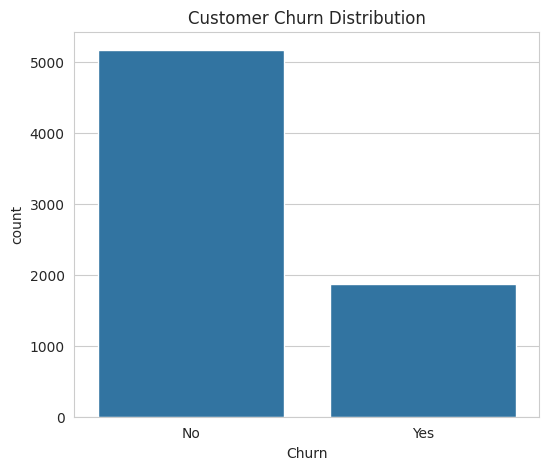

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

In [ ]:
#Churn percentage.
churn_rate = (
    df['Churn']
    .value_counts(normalize=True)
    *100
)

print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


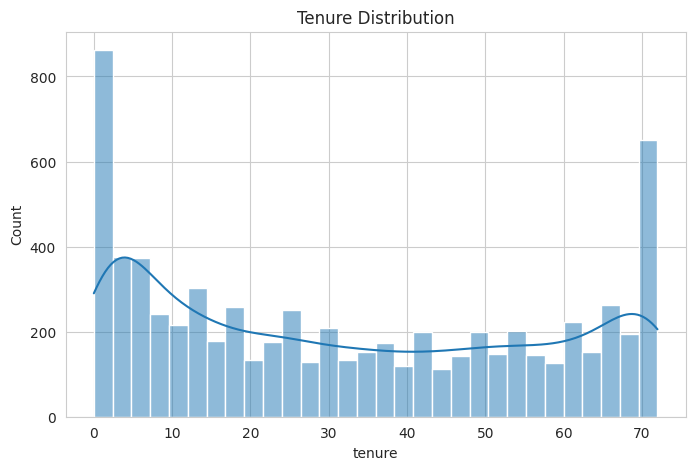

In [ ]:
#Numerical Feature Analysis
plt.figure(figsize=(8,5))

sns.histplot(
    df['tenure'],
    bins=30,
    kde=True
)

plt.title("Tenure Distribution")
plt.show()

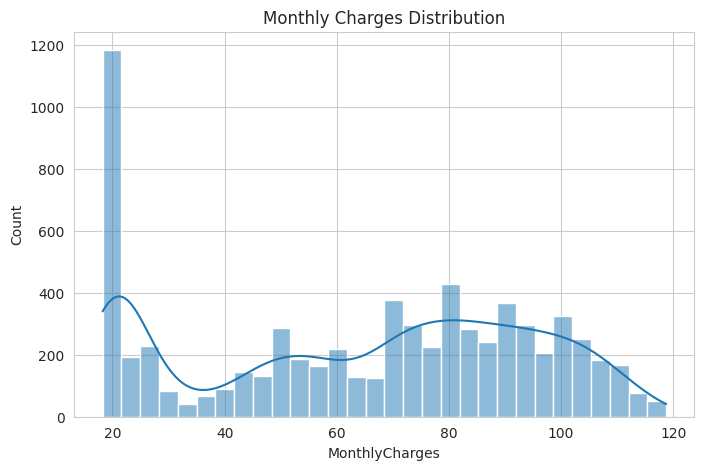

In [ ]:
#Monthly Charges
plt.figure(figsize=(8,5))

sns.histplot(
    df['MonthlyCharges'],
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.show()

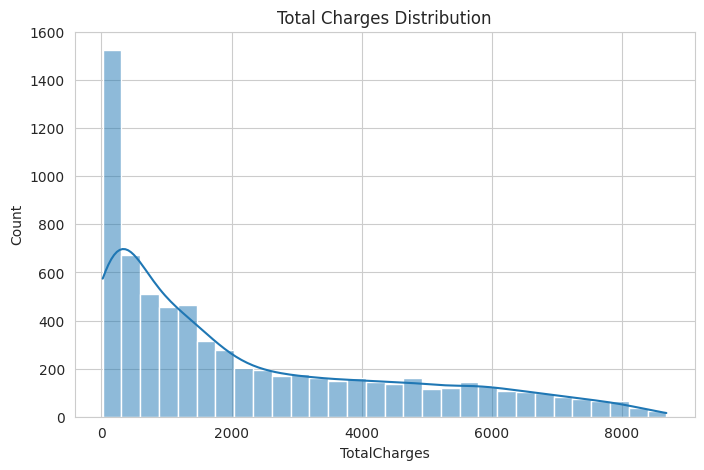

In [ ]:
#total Charges
plt.figure(figsize=(8,5))

sns.histplot(
    df['TotalCharges'],
    bins=30,
    kde=True
)

plt.title("Total Charges Distribution")
plt.show()

# Numerical Features vs Churn


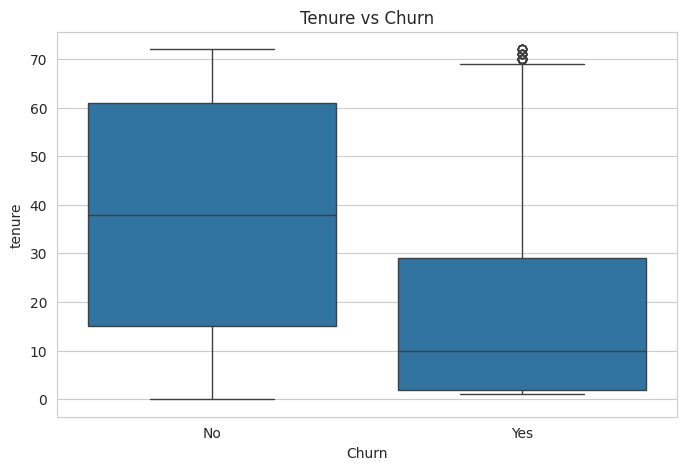

In [ ]:
#Tenure vs Churn

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

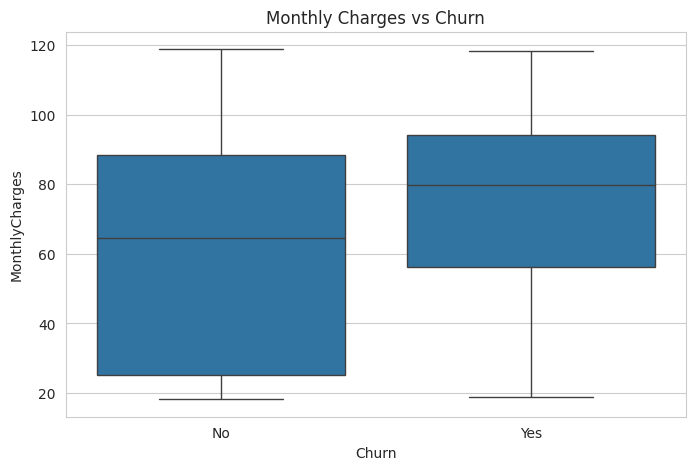

In [ ]:
#Monthly Charges vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

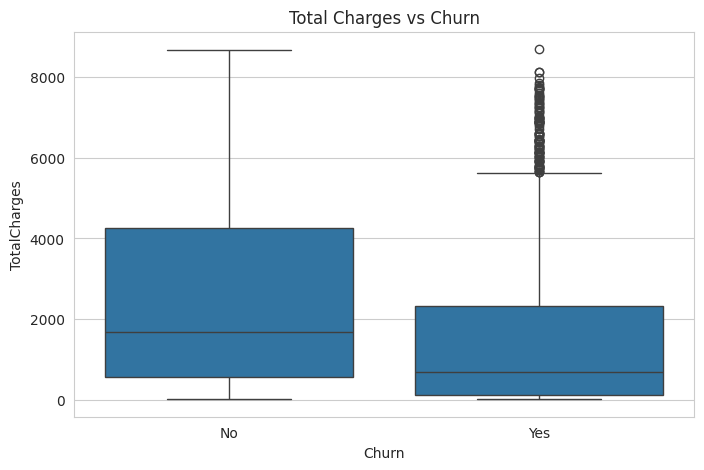

In [ ]:
#Total Charges vs Churn

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df
)

plt.title("Total Charges vs Churn")
plt.show()

# Categorical Features Analysis

In [ ]:
#Creating reusable function
def churn_plot(feature):
    churn_data = pd.crosstab(
        df[feature],
        df['Churn'],
        normalize='index'
    )*100

    churn_data.plot(
        kind='bar',
        stacked=True,
        figsize=(8,5)
    )

    plt.title(f"Churn Analysis : {feature}")
    plt.ylabel("Percentage")
    plt.show()


# Analyze Key Features

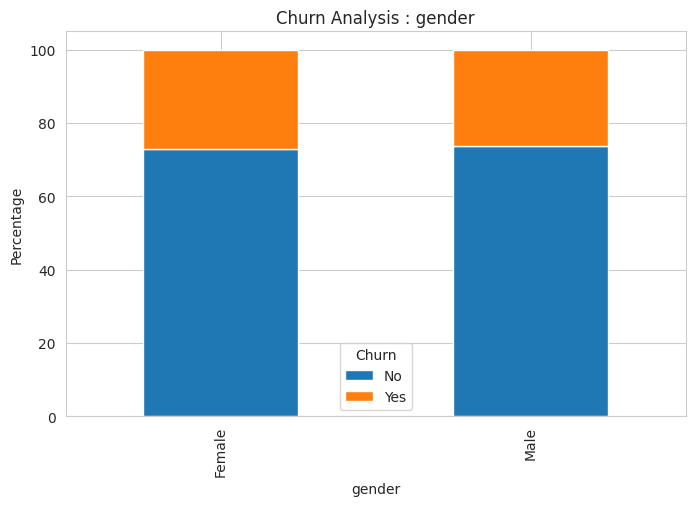

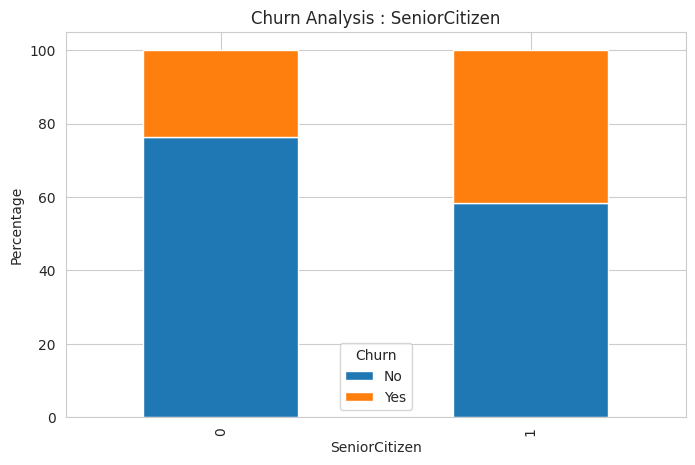

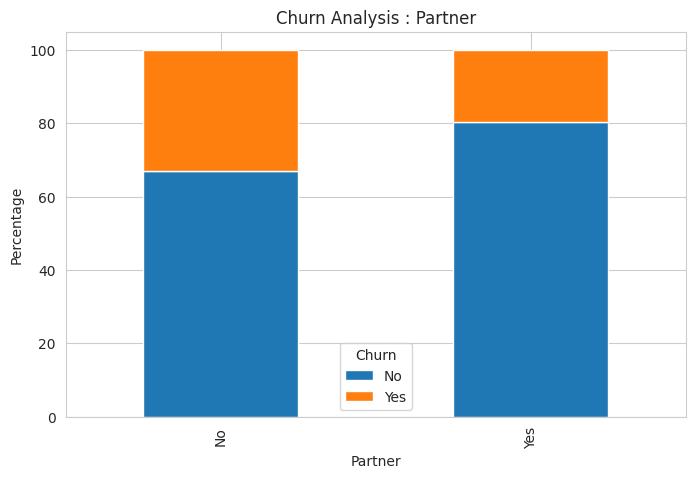

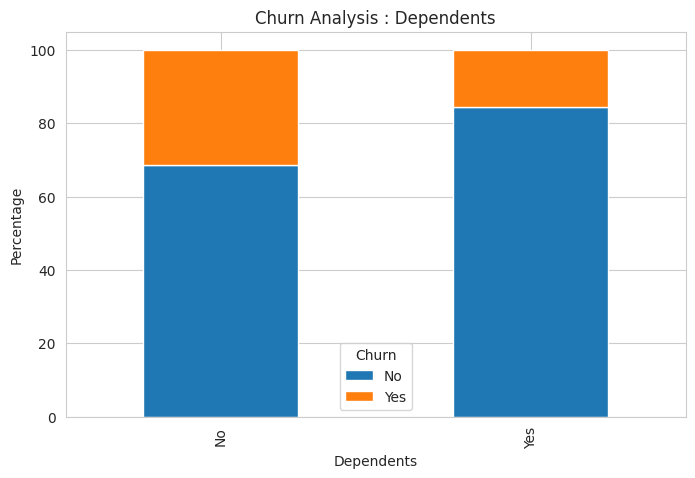

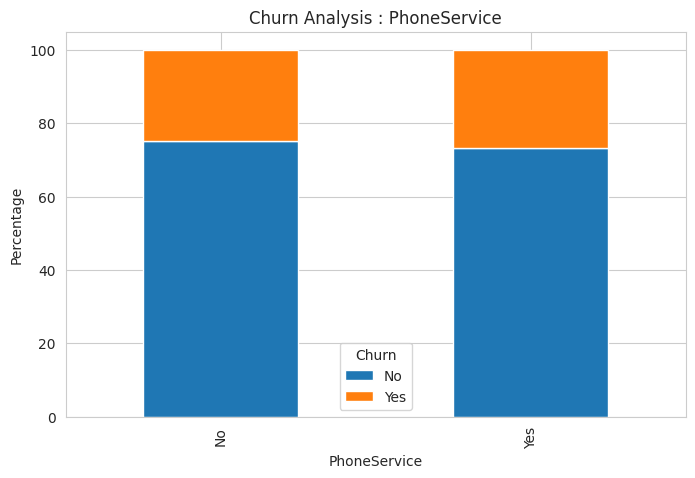

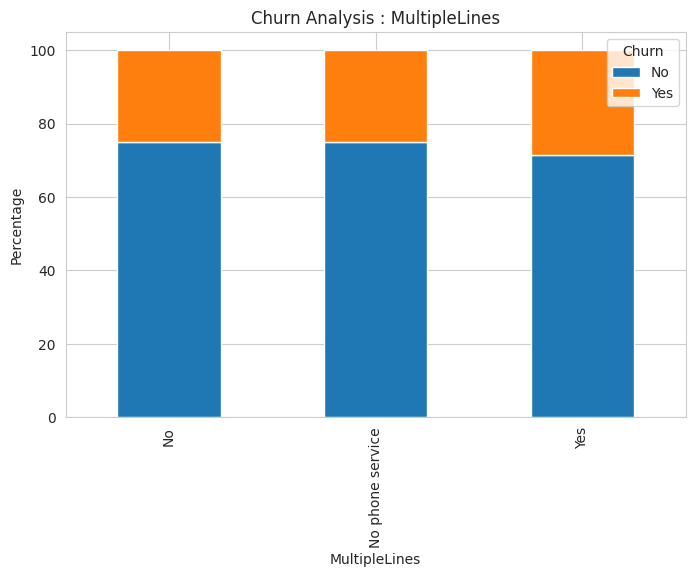

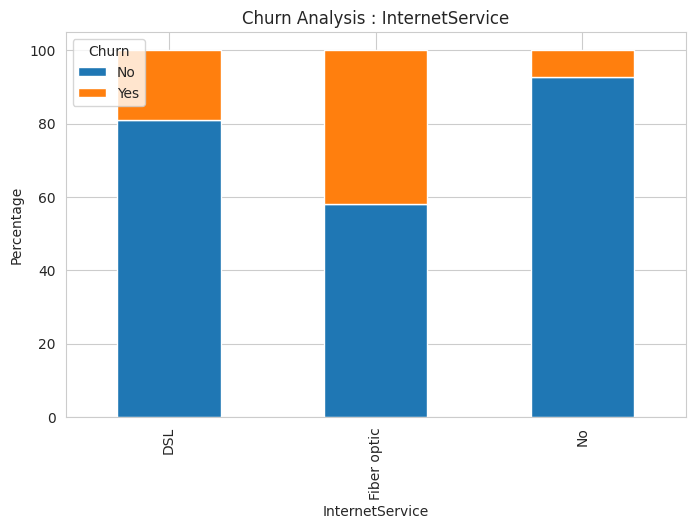

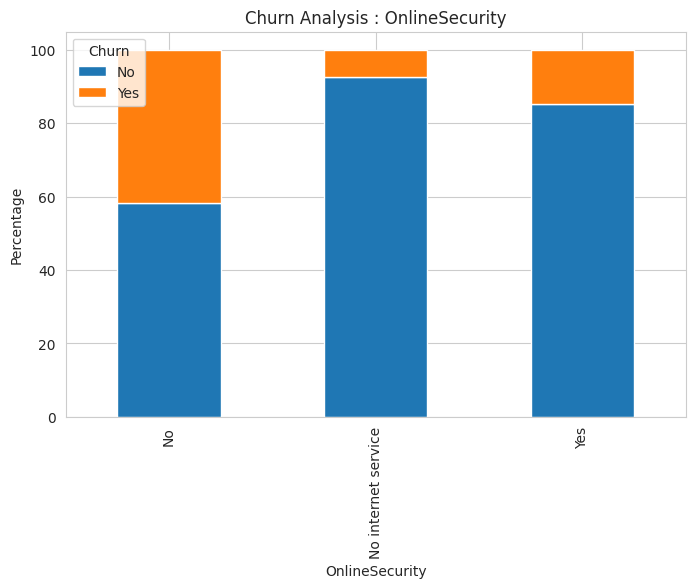

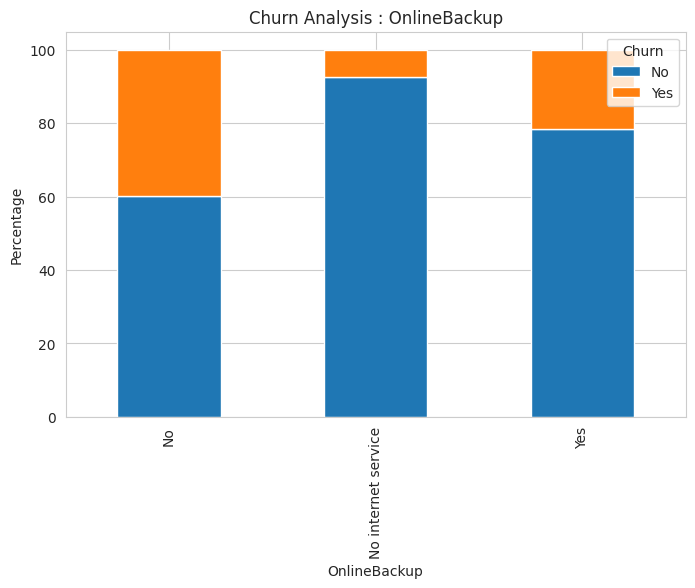

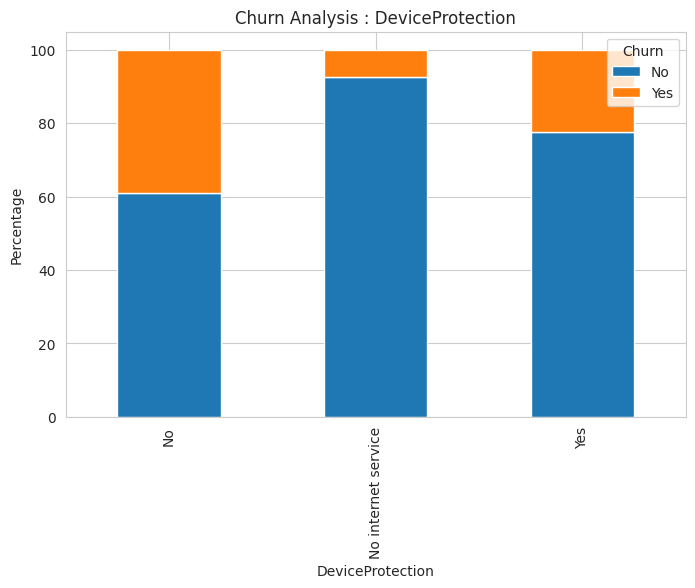

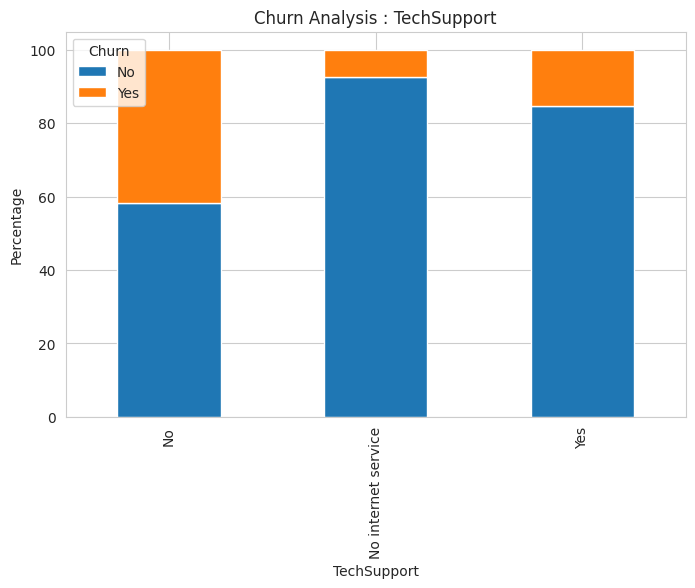

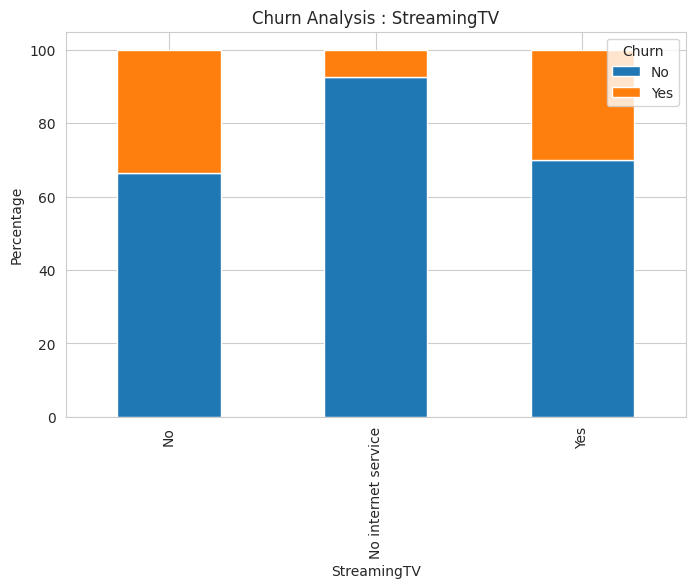

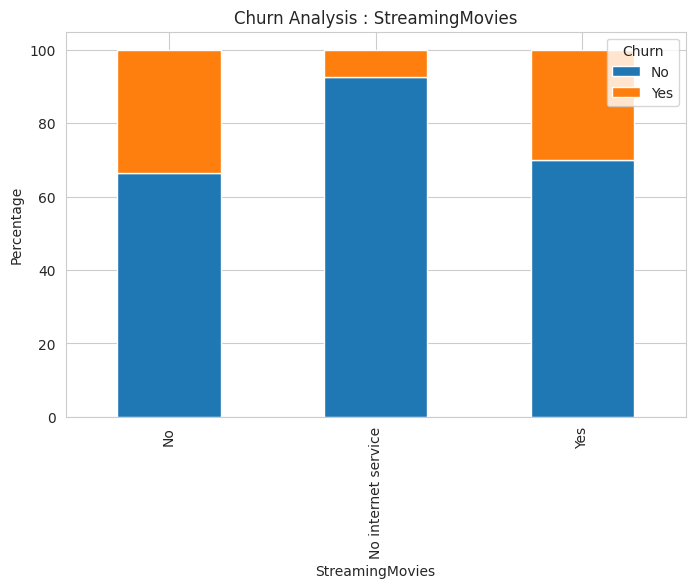

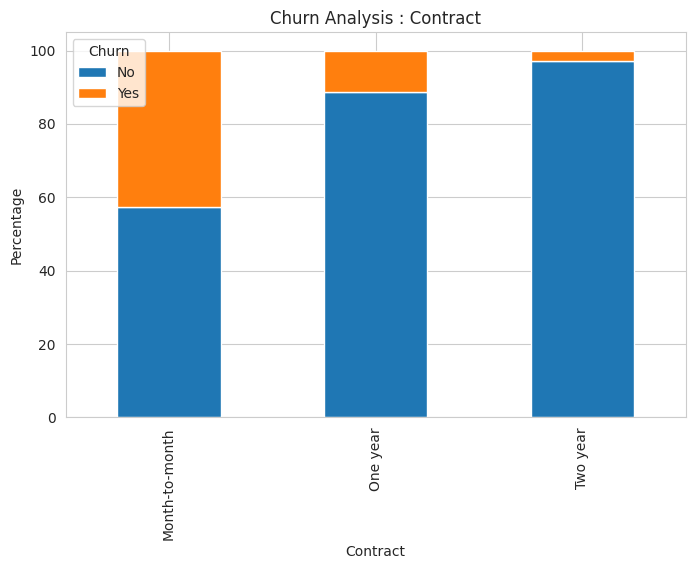

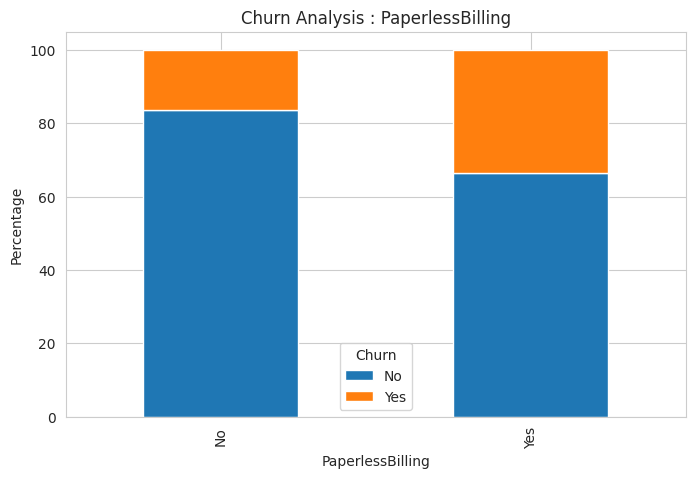

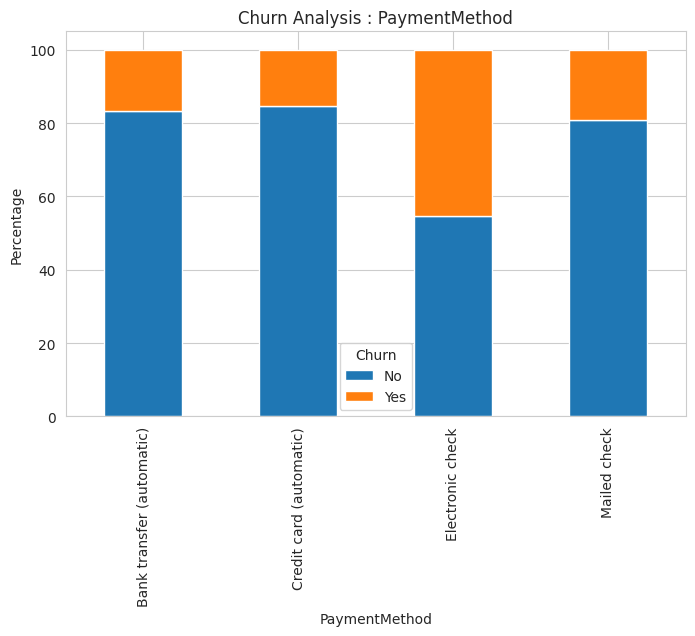

In [ ]:
features = [

'gender',
'SeniorCitizen',
'Partner',
'Dependents',
'PhoneService',
'MultipleLines',
'InternetService',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies',
'Contract',
'PaperlessBilling',
'PaymentMethod'

]

for feature in features:
    churn_plot(feature)

# Contract vs Churn

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


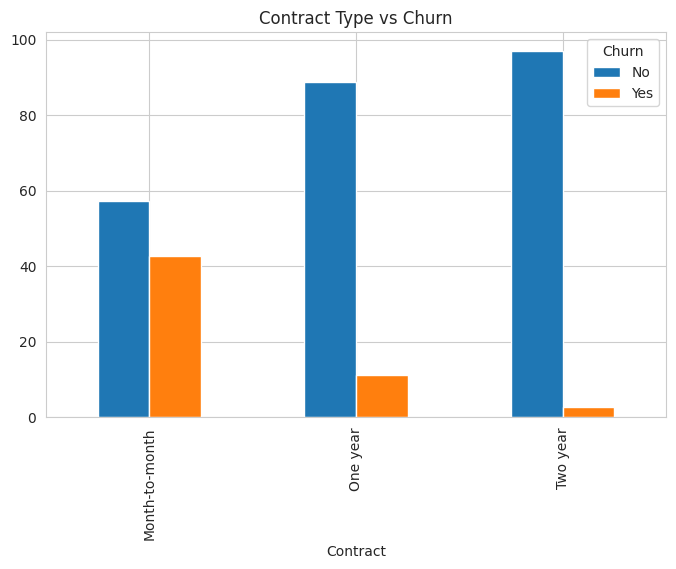

In [ ]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100

print(contract_churn)

contract_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Contract Type vs Churn")
plt.show()

# Internet Service vs Churn

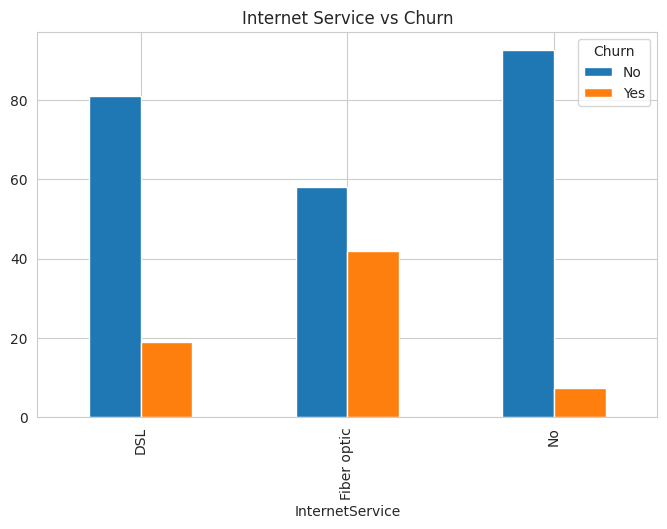

In [ ]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
)*100

internet_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Internet Service vs Churn")
plt.show()

#Payment Method vs Churn

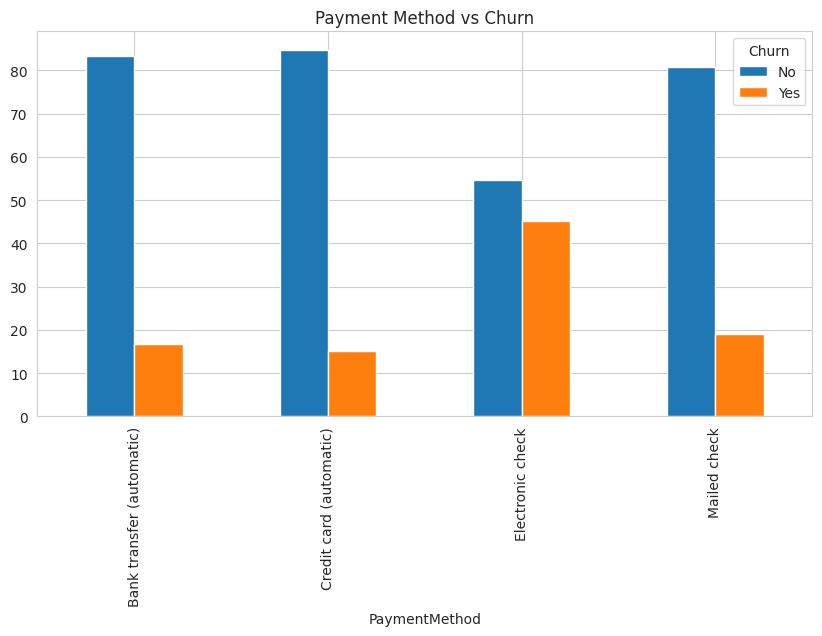

In [ ]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
)*100

payment_churn.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Payment Method vs Churn")
plt.show()

#Tenure Groups

In [ ]:
bins = [0,12,24,48,72]

labels = [
'0-12',
'12-24',
'24-48',
'48-72'
]

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels
)

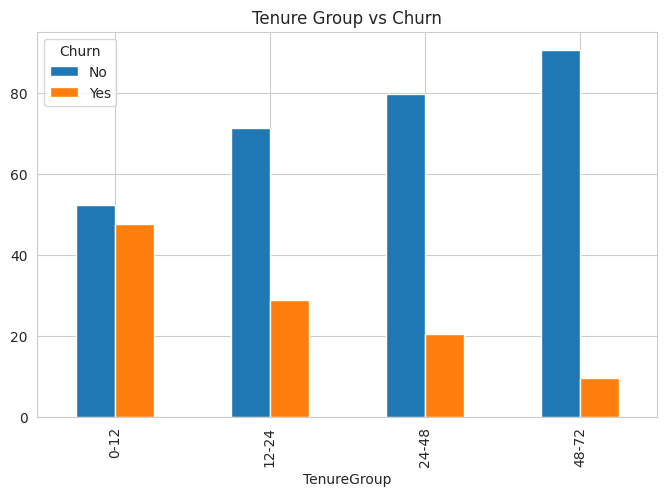

In [ ]:
tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
)*100

tenure_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Tenure Group vs Churn")
plt.show()

#Correlation Heatmap

In [ ]:
#Converting target
df['Churn_num'] = df['Churn'].map(
    {'Yes':1,'No':0}
)

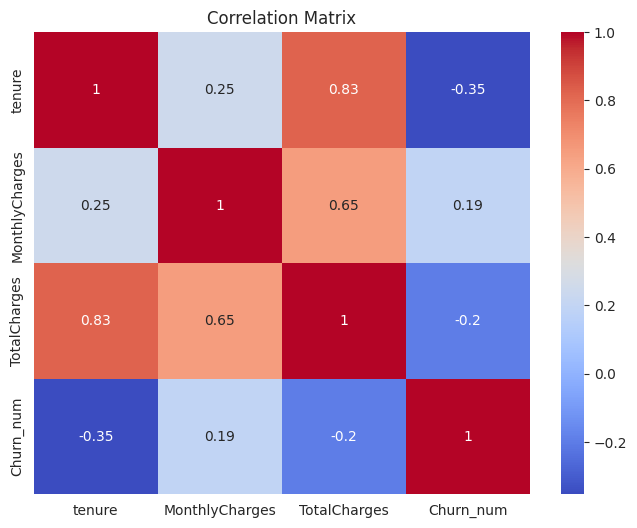

In [ ]:
#Numerical variables
corr_cols = [
'tenure',
'MonthlyCharges',
'TotalCharges',
'Churn_num'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# Chi-Square Test

In [ ]:
categorical_cols = [
'gender',
'Partner',
'Dependents',
'PhoneService',
'MultipleLines',
'InternetService',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies',
'Contract',
'PaperlessBilling',
'PaymentMethod'
]

In [ ]:
for col in categorical_cols:

    contingency = pd.crosstab(
        df[col],
        df['Churn']
    )

    chi2,p,dof,exp = chi2_contingency(
        contingency
    )

    print(
        f"{col:20} p-value = {p:.10f}"
    )

gender               p-value = 0.4865787361
Partner              p-value = 0.0000000000
Dependents           p-value = 0.0000000000
PhoneService         p-value = 0.3387825358
MultipleLines        p-value = 0.0034643830
InternetService      p-value = 0.0000000000
OnlineSecurity       p-value = 0.0000000000
OnlineBackup         p-value = 0.0000000000
DeviceProtection     p-value = 0.0000000000
TechSupport          p-value = 0.0000000000
StreamingTV          p-value = 0.0000000000
StreamingMovies      p-value = 0.0000000000
Contract             p-value = 0.0000000000
PaperlessBilling     p-value = 0.0000000000
PaymentMethod        p-value = 0.0000000000


**Interpretation
p < 0.05
means feature significantly impacts churn.**

# T-Test

In [ ]:
#Tenure
churn = df[df['Churn']=='Yes']

no_churn = df[df['Churn']=='No']

ttest_ind(
    churn['tenure'],
    no_churn['tenure']
)

TtestResult(statistic=np.float64(-31.57955051135377), pvalue=np.float64(7.99905796059022e-205), df=np.float64(7041.0))

In [ ]:
#Monthly Charges
ttest_ind(
    churn['MonthlyCharges'],
    no_churn['MonthlyCharges']
)

TtestResult(statistic=np.float64(16.536738015936308), pvalue=np.float64(2.7066456068884154e-60), df=np.float64(7041.0))

In [ ]:
#Total Charges
ttest_ind(
    churn['TotalCharges'],
    no_churn['TotalCharges']
)

TtestResult(statistic=np.float64(-17.04229535246348), pvalue=np.float64(7.508609056708869e-64), df=np.float64(7041.0))

## Applying Machine Learning

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Prepare Features and Target

In [ ]:
#Removed customerID because it has no predictive value.

df.drop('customerID', axis=1, inplace=True)
# Convert target
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify Categorical and Numerical Columns

In [ ]:
categorical_cols = X.select_dtypes(
    include='object'
).columns

numerical_cols = X.select_dtypes(
    exclude='object'
).columns

print(categorical_cols)
print(numerical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'TenureGroup', 'Churn_num'],
      dtype='object')


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_encoded = xgb_pipeline.named_steps['preprocessor'].transform(X_train)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    4139
1    4139
Name: count, dtype: int64


#Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Preprocessing

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ],
    remainder='passthrough'
)

#Applying Random Forest Model

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model',
     RandomForestClassifier(
         n_estimators=1000,
         max_depth=10,
         random_state=42,
         class_weight='balanced'
     ))
])

In [ ]:
X_train = X_train.drop(columns=['Churn_num'], errors='ignore')
X_test = X_test.drop(columns=['Churn_num'], errors='ignore')

all_cols = X_train.columns.tolist()
categorical_cols_updated = [col for col in all_cols if X_train[col].dtype == 'object' or X_train[col].dtype.name == 'category']
numerical_cols_updated = [col for col in all_cols if col not in categorical_cols_updated]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_updated),
        ('num', 'passthrough', numerical_cols_updated)
    ],
    remainder='drop'
)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup']),
                                                 ('num', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, random_state=42))])

In [ ]:
#Predictions:

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

In [ ]:
#Metrics:

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.7672107877927609
Precision: 0.5475206611570248
Recall: 0.7085561497326203
F1 Score: 0.6177156177156177
ROC-AUC: 0.8397349453615438


In [ ]:
pip install xgboost

In [ ]:
#Create Model:

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model',
     XGBClassifier(
         n_estimators=300,
         learning_rate=0.05,
         max_depth=5,
         subsample=0.8,
         colsample_bytree=0.8,
         random_state=42,
         eval_metric='logloss'
     ))
])

In [ ]:
#Train

xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
#Predictions :

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

In [ ]:
#Metrics:

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("Precision:",
      precision_score(y_test, y_pred_xgb))

print("Recall:",
      recall_score(y_test, y_pred_xgb))

print("F1 Score:",
      f1_score(y_test, y_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.7991483321504613
Precision: 0.6491803278688525
Recall: 0.5294117647058824
F1 Score: 0.5832106038291606
ROC-AUC: 0.8354013278565707


#Confusion Matrix

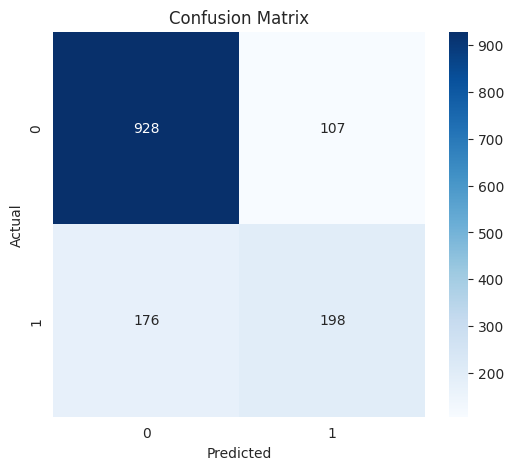

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



# Feature Importance

In [ ]:
encoder = xgb_pipeline.named_steps[
    'preprocessor'
]

feature_names = (
    encoder
    .get_feature_names_out()
)

importances = (
    xgb_pipeline
    .named_steps['model']
    .feature_importances_
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = (
    importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
)

print(
    importance_df.head(15)
)

                                    Feature  Importance
32             cat__Contract_Month-to-month    0.285901
12         cat__InternetService_Fiber optic    0.088034
13                  cat__InternetService_No    0.070977
41                    cat__TenureGroup_0-12    0.050944
15  cat__OnlineSecurity_No internet service    0.044792
14                   cat__OnlineSecurity_No    0.040963
34                   cat__Contract_Two year    0.036542
11                 cat__InternetService_DSL    0.029872
23                      cat__TechSupport_No    0.019162
31                 cat__StreamingMovies_Yes    0.019026
33                   cat__Contract_One year    0.018597
47                              num__tenure    0.013315
18    cat__OnlineBackup_No internet service    0.013063
39      cat__PaymentMethod_Electronic check    0.012720
28                     cat__StreamingTV_Yes    0.011877


Handling class imbalance , as data is imbalance

In [ ]:
#Use Stratified Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Random Forest with Class Weights
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

In [ ]:
#XGBoost with scale_pos_weight
neg = y_train.value_counts()[0]
pos = y_train.value_counts()[1]

scale_pos_weight = neg / pos

print(scale_pos_weight)

2.768561872909699


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

In [ ]:
#SMOTE (Synthetic Minority Oversampling)
pip install imbalanced-learn

In [ ]:
#applyin only on taining data
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_encoded = xgb_pipeline.named_steps['preprocessor'].transform(X_train)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    4139
1    4139
Name: count, dtype: int64


In [ ]:
#Borderline SMOTE (Better)
from imblearn.over_sampling import BorderlineSMOTE

smote = BorderlineSMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded,
    y_train
)

In [ ]:
#ADASYN
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(
    X_train_encoded,
    y_train
)

In [ ]:
#Threshold Tuning (Very Effective)
#Predict probabilities:
X_test_encoded = xgb_pipeline.named_steps['preprocessor'].transform(X_test)
y_prob = xgb_pipeline.predict_proba(X_test)[:,1]

In [ ]:
#Changed threshold:
threshold = 0.35
y_pred = (y_prob >= threshold).astype(int)

In [ ]:
#Stratified Cross Validation
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# SHAP Explainability

In [ ]:
pip install shap

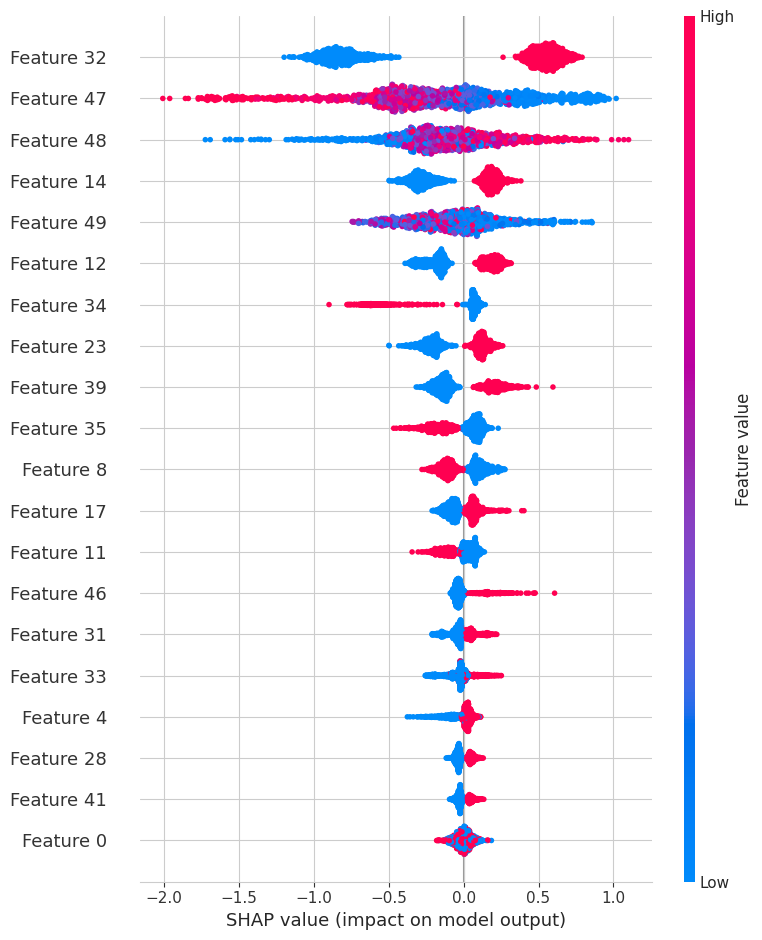

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_pipeline.named_steps['model'])

shap_values = explainer.shap_values(X_test_encoded)

shap.summary_plot(
    shap_values,
    X_test_encoded
)

### Hyperparameter Tuning with GridSearchCV
 using `GridSearchCV` to systematically work through multiple combinations of hyperparameters, cross-validating each combination and selecting the best performing set. This process can be computationally intensive but often yields better model performance.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_pipeline,  # Use the pipeline with preprocessor
    param_grid=param_grid,
    cv=cv,                   # Use the previously defined StratifiedKFold
    scoring='roc_auc',       # Optimize for ROC-AUC score
    n_jobs=-1,               # Use all available cores
    verbose=2                # Print progress
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'Streaming...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=300,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.7, 0.8, 0.9],
                         'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 300, 500],
                         'model__subsample': [0.7, 0.8, 0.9]},
             scoring='roc_auc', verbose=2)

#### Best Parameters and Best Score

After fitting the `GridSearchCV`, we can inspect the best parameters found and the corresponding best score achieved during cross-validation.

In [ ]:
print("Best parameters found:", grid_search.best_params_)
print("Best ROC-AUC score:", grid_search.best_score_)

Best parameters found: {'model__colsample_bytree': 0.9, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 0.7}
Best ROC-AUC score: 0.851050114552925


#### Evaluate Model with Best Parameters

let's get the best estimator (model with the best hyperparameters) from the grid search and evaluate its performance on the test set.

Tuned Model Accuracy: 0.8062455642299503
Tuned Model Precision: 0.6735395189003437
Tuned Model Recall: 0.5240641711229946
Tuned Model F1 Score: 0.5894736842105263
Tuned Model ROC-AUC: 0.8483957219251337

Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



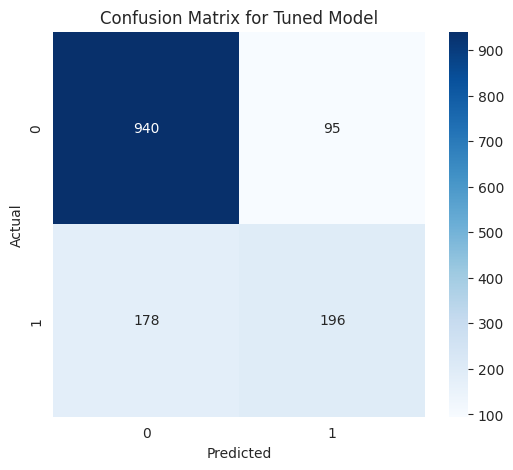

In [ ]:
# Get the best estimator
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred_tuned = best_xgb_model.predict(X_test)
y_prob_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

# Print evaluation metrics
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned Model Precision:", precision_score(y_test, y_pred_tuned))
print("Tuned Model Recall:", recall_score(y_test, y_pred_tuned))
print("Tuned Model F1 Score:", f1_score(y_test, y_pred_tuned))
print("Tuned Model ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))

print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned))

# Confusion Matrix for Tuned Model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Tuned Model")
plt.show()

### Hyperparameter Tuning with RandomizedSearchCV

While `GridSearchCV` exhaustively searches through all parameter combinations, `RandomizedSearchCV` samples a fixed number of settings from the hyperparameter distributions. This can be more efficient for large search spaces, allowing us to explore more diverse combinations in less time.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distributions for XGBoost
param_distributions = {
    'model__n_estimators': randint(100, 1000),  # Number of boosting rounds
    'model__learning_rate': uniform(0.01, 0.2), # Step size shrinkage
    'model__max_depth': randint(3, 10),         # Maximum depth of a tree
    'model__subsample': uniform(0.6, 0.4),      # Subsample ratio of the training instance
    'model__colsample_bytree': uniform(0.6, 0.4) # Subsample ratio of columns when constructing each tree
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,  # Use the pipeline with preprocessor
    param_distributions=param_distributions,
    n_iter=50,               # Number of parameter settings that are sampled
    cv=cv,                   # Use the previously defined StratifiedKFold
    scoring='roc_auc',       # Optimize for ROC-AUC score
    n_jobs=-1,               # Use all available cores
    random_state=42,         # For reproducibility
    verbose=2                # Print progress
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['gender',
                                                                                'Partner',
                                                                                'Dependents',
                                                                                'PhoneService',
                                                                                'MultipleLines',
                                                                                'InternetService',
                                                                                'OnlineSecurity',
                                                                                'OnlineBackup',
                                                                                'DeviceProtection',
                                                                                'TechSupport',
                                                                                'Str...
                                        'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4567712540>,
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4567996630>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f4567712b40>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4567997c80>},
                   random_state=42, scoring='roc_auc', verbose=2)

#### Best Parameters and Best Score from Randomized Search

Let's check the best parameters found by `RandomizedSearchCV` and its corresponding ROC-AUC score.

In [ ]:
print("Best parameters found by Randomized Search:", random_search.best_params_)
print("Best ROC-AUC score from Randomized Search:", random_search.best_score_)

Best parameters found by Randomized Search: {'model__colsample_bytree': np.float64(0.8446612641953124), 'model__learning_rate': np.float64(0.011413261043943482), 'model__max_depth': 3, 'model__n_estimators': 660, 'model__subsample': np.float64(0.8099098641033556)}
Best ROC-AUC score from Randomized Search: 0.8502144898973463


#### Evaluate Model with Best Parameters from Randomized Search

Finally, we'll evaluate the performance of the model using the best parameters identified by `RandomizedSearchCV` on the test set.

Random Search Tuned Model Accuracy: 0.8069552874378992
Random Search Tuned Model Precision: 0.673469387755102
Random Search Tuned Model Recall: 0.5294117647058824
Random Search Tuned Model F1 Score: 0.592814371257485
Random Search Tuned Model ROC-AUC: 0.8477589191144178

Classification Report for Random Search Tuned Model:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



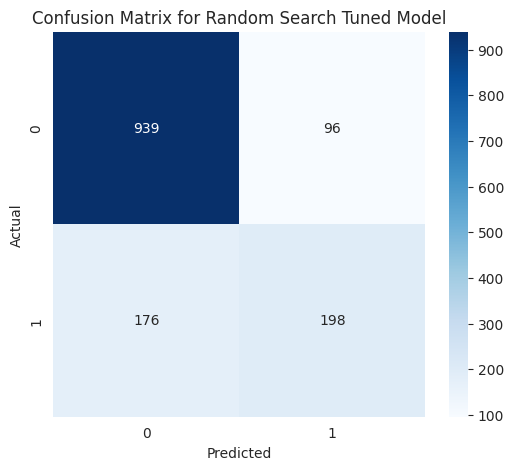

In [ ]:
# Get the best estimator from Randomized Search
best_xgb_model_random = random_search.best_estimator_

# Make predictions on the test set
y_pred_random = best_xgb_model_random.predict(X_test)
y_prob_random = best_xgb_model_random.predict_proba(X_test)[:, 1]

# Print evaluation metrics
print("Random Search Tuned Model Accuracy:", accuracy_score(y_test, y_pred_random))
print("Random Search Tuned Model Precision:", precision_score(y_test, y_pred_random))
print("Random Search Tuned Model Recall:", recall_score(y_test, y_pred_random))
print("Random Search Tuned Model F1 Score:", f1_score(y_test, y_pred_random))
print("Random Search Tuned Model ROC-AUC:", roc_auc_score(y_test, y_prob_random))

print("\nClassification Report for Random Search Tuned Model:")
print(classification_report(y_test, y_pred_random))

# Confusion Matrix for Random Search Tuned Model
cm_random = confusion_matrix(y_test, y_pred_random)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_random, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Random Search Tuned Model")
plt.show()

### Visual Comparison of Model Performance Metrics

To make the comparison of the models' performance easier to interpret, we will visualize their key metrics (Accuracy, Precision, Recall, F1 Score, and ROC-AUC) using a grouped bar chart.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Metrics for Random Forest --- #
# Assuming y_pred_rf and y_prob_rf are available from previous cells
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# --- Metrics for Original XGBoost --- #
# Assuming y_pred_xgb and y_prob_xgb are available from previous cells
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# --- Metrics for XGBoost with scale_pos_weight --- #
# We need to re-fit the xgb_pipeline_scaled to ensure it's available and has the scale_pos_weight applied
# and calculate its predictions and probabilities

# Recalculate scale_pos_weight (if not already in environment)
if 'scale_pos_weight' not in locals():
    neg = y_train.value_counts()[0]
    pos = y_train.value_counts()[1]
    scale_pos_weight = neg / pos
    print(f"Recalculated scale_pos_weight: {scale_pos_weight}")

# Define and fit xgb_pipeline_scaled if it's not defined or fitted correctly
if 'xgb_pipeline_scaled' not in locals() or not hasattr(xgb_pipeline_scaled, 'is_fitted_') or not xgb_pipeline_scaled.is_fitted_:
    print("Re-initializing and fitting xgb_pipeline_scaled...")
    xgb_pipeline_scaled = Pipeline([
        ('preprocessor', preprocessor),
        ('model',
         XGBClassifier(
             n_estimators=300,
             learning_rate=0.05,
             max_depth=5,
             subsample=0.8,
             colsample_bytree=0.8,
             random_state=42,
             eval_metric='logloss',
             scale_pos_weight=scale_pos_weight  # Apply cost-sensitive learning here
         ))
    ])
    xgb_pipeline_scaled.fit(X_train, y_train)
    y_pred_xgb_scaled = xgb_pipeline_scaled.predict(X_test)
    y_prob_xgb_scaled = xgb_pipeline_scaled.predict_proba(X_test)[:, 1]

accuracy_xgb_scaled = accuracy_score(y_test, y_pred_xgb_scaled)
precision_xgb_scaled = precision_score(y_test, y_pred_xgb_scaled)
recall_xgb_scaled = recall_score(y_test, y_pred_xgb_scaled)
f1_xgb_scaled = f1_score(y_test, y_pred_xgb_scaled)
roc_auc_xgb_scaled = roc_auc_score(y_test, y_prob_xgb_scaled)

# Create a DataFrame for comparison
metrics_data = {
    'Model': ['Random Forest', 'XGBoost (Original)', 'XGBoost (Scaled)'],
    'Accuracy': [accuracy_rf, accuracy_xgb, accuracy_xgb_scaled],
    'Precision': [precision_rf, precision_xgb, precision_xgb_scaled],
    'Recall': [recall_rf, recall_xgb, recall_xgb_scaled],
    'F1 Score': [f1_rf, f1_xgb, f1_xgb_scaled],
    'ROC-AUC': [roc_auc_rf, roc_auc_xgb, roc_auc_xgb_scaled]
}

metrics_df = pd.DataFrame(metrics_data)

print("Performance Metrics Comparison:")
display(metrics_df)


Re-initializing and fitting xgb_pipeline_scaled...
Performance Metrics Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.767211,0.547521,0.708556,0.617716,0.839735
1,XGBoost (Original),0.799148,0.649180,0.529412,0.583211,0.835401
2,XGBoost (Scaled),0.757275,0.530418,0.745989,0.620000,0.835166


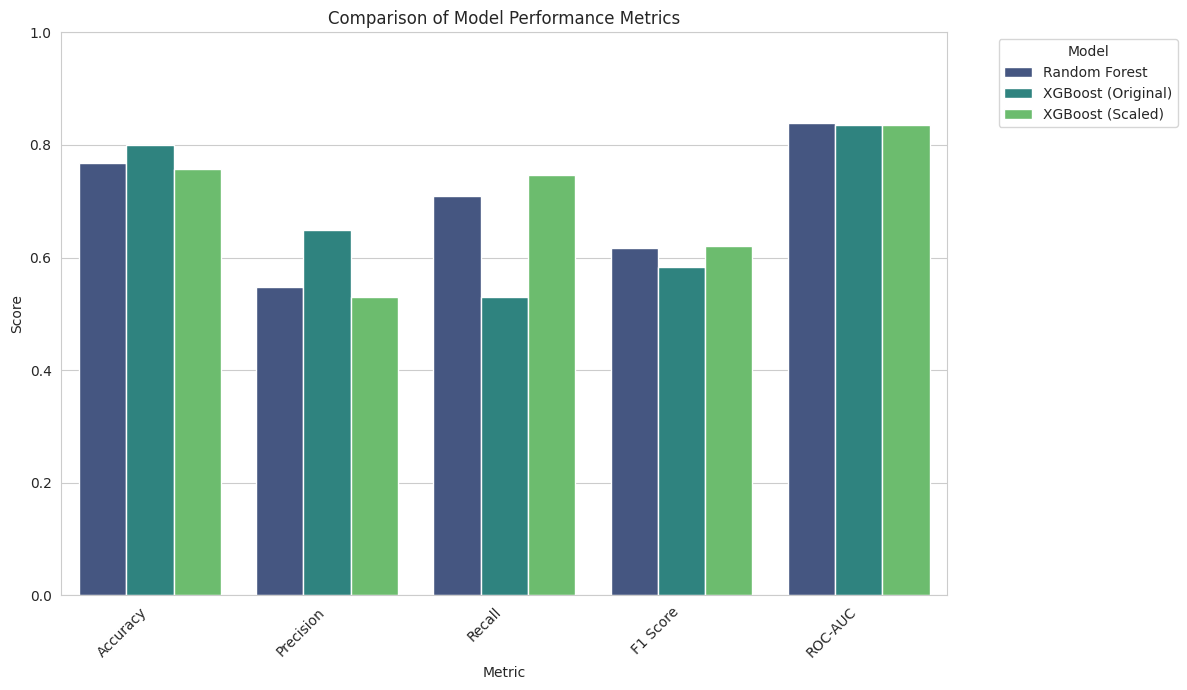

In [ ]:
# Plotting the comparison
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()